In [1]:
import os, glob, numpy as np, matplotlib.pyplot as plt, ipywidgets as W
from xmitgcm.utils import read_mds
from pathlib import Path

grid_dir  = Path('.').resolve()

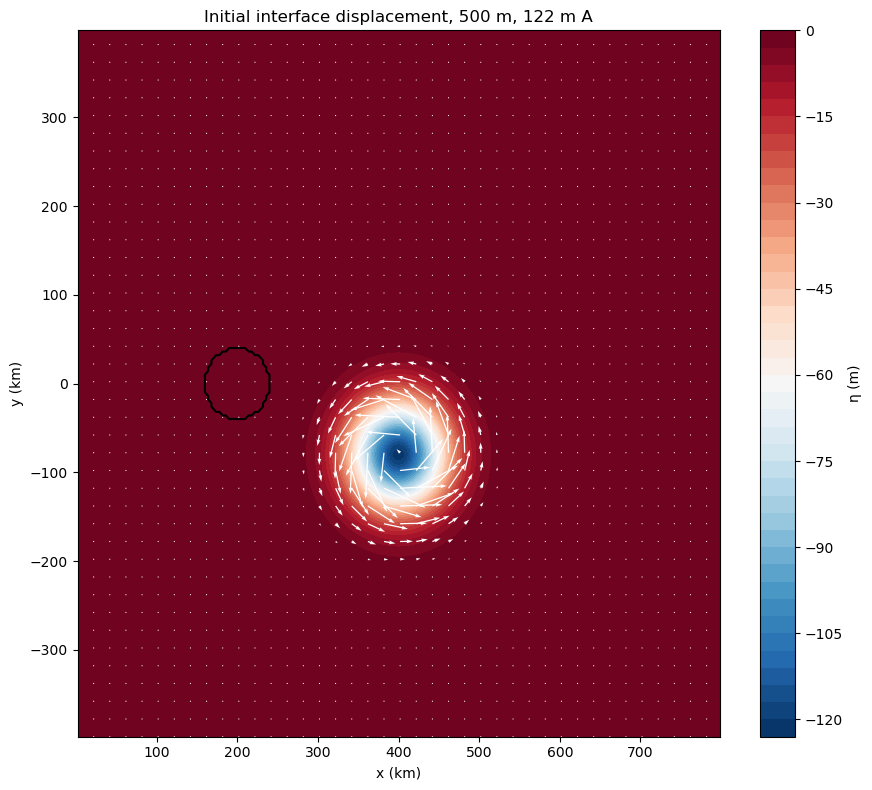

Max velocity magnitude: 0.7403 m/s


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

# Paths

Nx, Ny = 200, 200
dx, dy = 4000, 4000


# Load binary files
eta  = np.fromfile(f"{grid_dir}/etaInit_a.bin",  dtype=">f8").reshape(Ny, Nx)
u    = np.fromfile(f"{grid_dir}/uVelInit_a.bin", dtype=">f8").reshape(1, Ny, Nx)[0]
v    = np.fromfile(f"{grid_dir}/vVelInit_a.bin", dtype=">f8").reshape(1, Ny, Nx)[0]
bathy = np.fromfile(f"{grid_dir}/bathy.bin",   dtype=">f8").reshape(Ny, Nx)

land  = (bathy == 0)     # mask for island
# Make coordinates
x = (np.arange(Nx)+0.5)*dx
y = (np.arange(Ny)+0.5)*dy - 0.5*Ny*dy
X,Y = np.meshgrid(x,y,indexing="xy")

# Plot SSH + island outline
plt.figure(figsize=(9,8))
plt.contourf(X/1000, Y/1000, eta, 40, cmap="RdBu_r")

plt.colorbar(label="η (m)")
plt.contour(X/1000, Y/1000, bathy==0, levels=[0.5], colors="k")
plt.quiver(X[::5,::5]/1000, Y[::5,::5]/1000, u[::5,::5], v[::5,::5], 
           scale=10, width=0.002, color="white")
plt.title("Initial interface displacement, 500 m, 122 m A")
plt.xlabel("x (km)")
plt.ylabel("y (km)")
plt.tight_layout()
plt.show()

# Compute velocity magnitude
vel_mag = np.sqrt(u**2 + v**2)

# Print max velocity
print(f"Max velocity magnitude: {vel_mag.max():.4f} m/s")

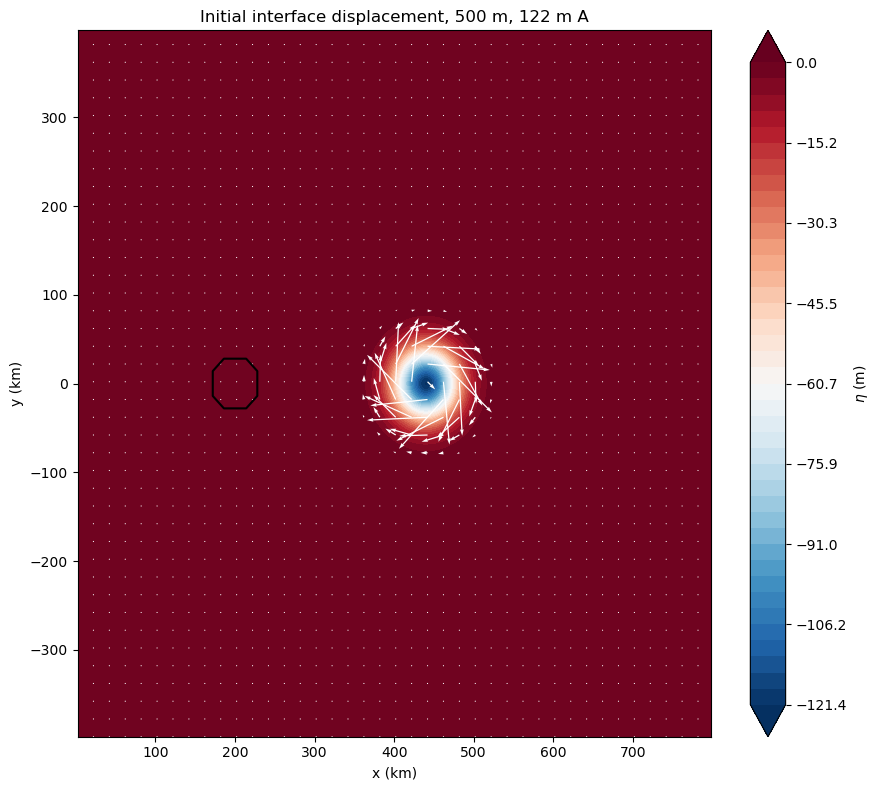

Max velocity magnitude: 1.0886 m/s


In [10]:
import numpy as np
import matplotlib.pyplot as plt

# grid / sizes
Nx, Ny = 200, 200
dx, dy = 4000, 4000

# Load binary files
eta   = np.fromfile(f"{grid_dir}/etaInit_a.bin",  dtype=">f8").reshape(Ny, Nx)
u     = np.fromfile(f"{grid_dir}/uVelInit_a.bin", dtype=">f8").reshape(1, Ny, Nx)[0]
v     = np.fromfile(f"{grid_dir}/vVelInit_a.bin", dtype=">f8").reshape(1, Ny, Nx)[0]
bathy = np.fromfile(f"{grid_dir}/bathy.bin",      dtype=">f8").reshape(Ny, Nx)

land = (bathy == 0)

# Coordinates (m → km)
x = (np.arange(Nx) + 0.5) * dx
y = (np.arange(Ny) + 0.5) * dy - 0.5 * Ny * dy
X, Y = np.meshgrid(x, y, indexing="xy")

# ---- FIX THE COLOR RANGE ----
# eddy is a negative anomaly, outside is 0
emin = float(np.nanmin(eta))   # ~ -122 m
vmin, vmax = emin, 0.0         # show [-122, 0], 0 at top of bar

levels = np.linspace(vmin, vmax, 41)

plt.figure(figsize=(9, 8))

cf = plt.contourf(X/1000, Y/1000, eta,
                  levels=levels, cmap="RdBu_r",
                  vmin=-122, vmax=0, extend="both")

cbar = plt.colorbar(cf)
cbar.set_label(r"$\eta$ (m)")

# island outline
plt.contour(X/1000, Y/1000, land, levels=[0.5], colors="k")

# velocities
plt.quiver(X[::5, ::5] / 1000, Y[::5, ::5] / 1000,
           u[::5, ::5], v[::5, ::5],
           scale=10, width=0.002, color="white")

plt.title("Initial interface displacement, 500 m, 122 m A")
plt.xlabel("x (km)")
plt.ylabel("y (km)")
plt.tight_layout()
plt.show()

# velocity magnitude
vel_mag = np.sqrt(u**2 + v**2)
print(f"Max velocity magnitude: {vel_mag.max():.4f} m/s")